<a href="https://colab.research.google.com/github/mkRuby009/nmcn_course/blob/W0_foundations/LIFNeuron_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Figure settings

In [ ]:
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/content-creation/main/nma.mplstyle")

## Helper functions

In [ ]:
t_max = 150e-3   # second
dt = 1e-3        # second
tau = 20e-3      # second
el = -60e-3      # milivolt
vr = -70e-3      # milivolt
vth = -50e-3     # milivolt
r = 100e6        # ohm
i_mean = 25e-11  # ampere


def plot_all(t_range, v, raster=None, spikes=None, spikes_mean=None):
  """
  Plots Time evolution for
  (1) multiple realizations of membrane potential
  (2) spikes
  (3) mean spike rate (optional)

  Args:
    t_range (numpy array of floats)
        range of time steps for the plots of shape (time steps)

    v (numpy array of floats)
        membrane potential values of shape (neurons, time steps)

    raster (numpy array of floats)
        spike raster of shape (neurons, time steps)

    spikes (dictionary of lists)
        list with spike times indexed by neuron number

    spikes_mean (numpy array of floats)
        Mean spike rate for spikes as dictionary

  Returns:
    Nothing.
  """

  v_mean = np.mean(v, axis=0)
  fig_w, fig_h = plt.rcParams['figure.figsize']
  plt.figure(figsize=(fig_w, 1.5 * fig_h))

  ax1 = plt.subplot(3, 1, 1)
  for j in range(n):
    plt.scatter(t_range, v[j], color="k", marker=".", alpha=0.01)
  plt.plot(t_range, v_mean, 'C1', alpha=0.8, linewidth=3)
  plt.xticks([])
  plt.ylabel(r'$V_m$ (V)')

  if raster is not None:
    plt.subplot(3, 1, 2)
    spikes_mean = np.mean(raster, axis=0)
    plt.imshow(raster, cmap='Greys', origin='lower', aspect='auto')

  else:
    plt.subplot(3, 1, 2, sharex=ax1)
    for j in range(n):
      times = np.array(spikes[j])
      plt.scatter(times, j * np.ones_like(times), color="C0", marker=".", alpha=0.2)

  plt.xticks([])
  plt.ylabel('neuron')

  if spikes_mean is not None:
    plt.subplot(3, 1, 3, sharex=ax1)
    plt.plot(t_range, spikes_mean)
    plt.xlabel('time (s)')
    plt.ylabel('rate (Hz)')

  plt.tight_layout()
  plt.show()

# Coding Exercise 1: Plotting a histogram

Plot an histogram of J=50 bins of N=10000 realizations of V(t) for t=tmax/10 and t=tmax.

We'll make a small correction in the definition of t_range to ensure increments of dt by using np.arange instead of np.linspace.

```
numpy.arange(start, stop, step)
```


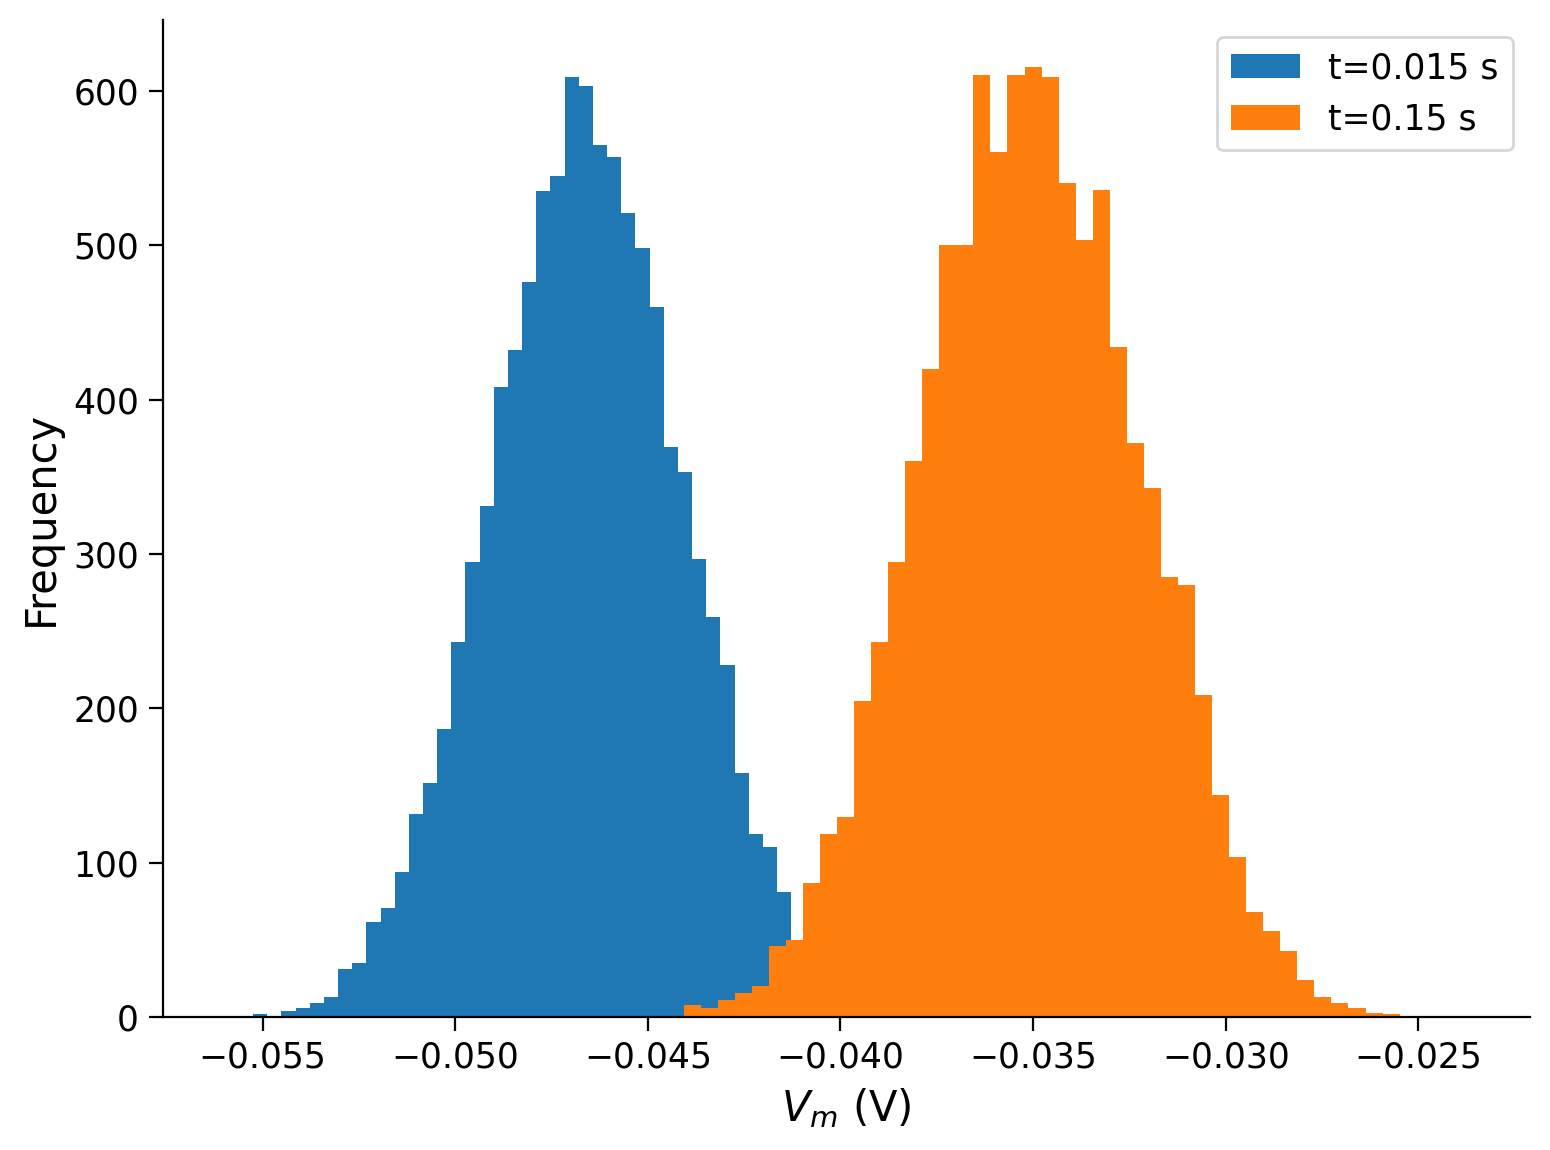

In [ ]:
# Set random number generator
np.random.seed(2020)

# Initialize t_range, step_end, n, v_n, i and nbins
t_range = np.arange(0, t_max, dt)
step_end = len(t_range)
n = 10000
v_n = el * np.ones([n, step_end])
i = i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * (2 * np.random.random([n, step_end]) - 1))
nbins = 50

# Loop over time steps
for step, t in enumerate(t_range):

  # Skip first iteration
  if step==0:
    continue

  # Compute v_n
  v_n[:, step] =  v_n[:, step - 1] + (dt / tau) * (el - v_n[:, step - 1] + r * i[:, step])

# Initialize the figure
plt.figure()
plt.ylabel('Frequency')
plt.xlabel('$V_m$ (V)')

# Plot a histogram at t_max/10 (add labels and parameters histtype='stepfilled' and linewidth=0)
plt.hist(v_n[:, int(step_end/10)], nbins, histtype='stepfilled', linewidth=0, label=f't={t_max/10} s')

# Plot a histogram at t_max (add labels and parameters histtype='stepfilled' and linewidth=0)
plt.hist(v_n[:, -1], nbins, histtype='stepfilled', linewidth=0, label=f't={t_max} s')

# Add legend
plt.legend()
plt.show()

# Coding Exercise 2: Adding spiking to the LIF neuron

Insert the reset condition, and collect the spike times of each realization in a dictionary variable spikes, with N=500.

We've used plt.plot for plotting lines and also for plotting dots at (x,y) coordinates, which is a scatter plot. From here on, we'll use use plt.plot for plotting lines and for scatter plots: plt.scatter.
```
plt.scatter(x, y, color="k", marker=".")
```
A raster plot represents spikes from multiple neurons by plotting dots at spike times from neuron j at plot height j, i.e.
```
plt.scatter(spike_times, j*np.ones_like(spike_times))   
```

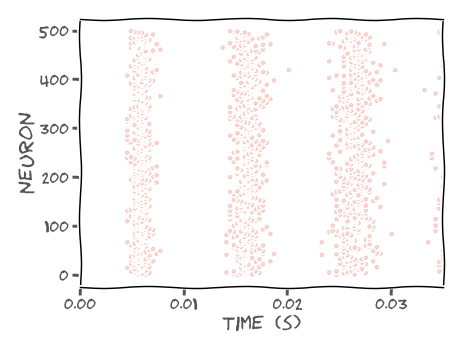

   

In this exercise, we use plt.subplot for multiple plots in the same figure. These plots can share the same x or y axis by specifying the parameter sharex or sharey. Add plt.tight_layout() at the end to automatically adjust subplot parameters to fit the figure area better. Please see the example below for a row of two plots sharing axis y.

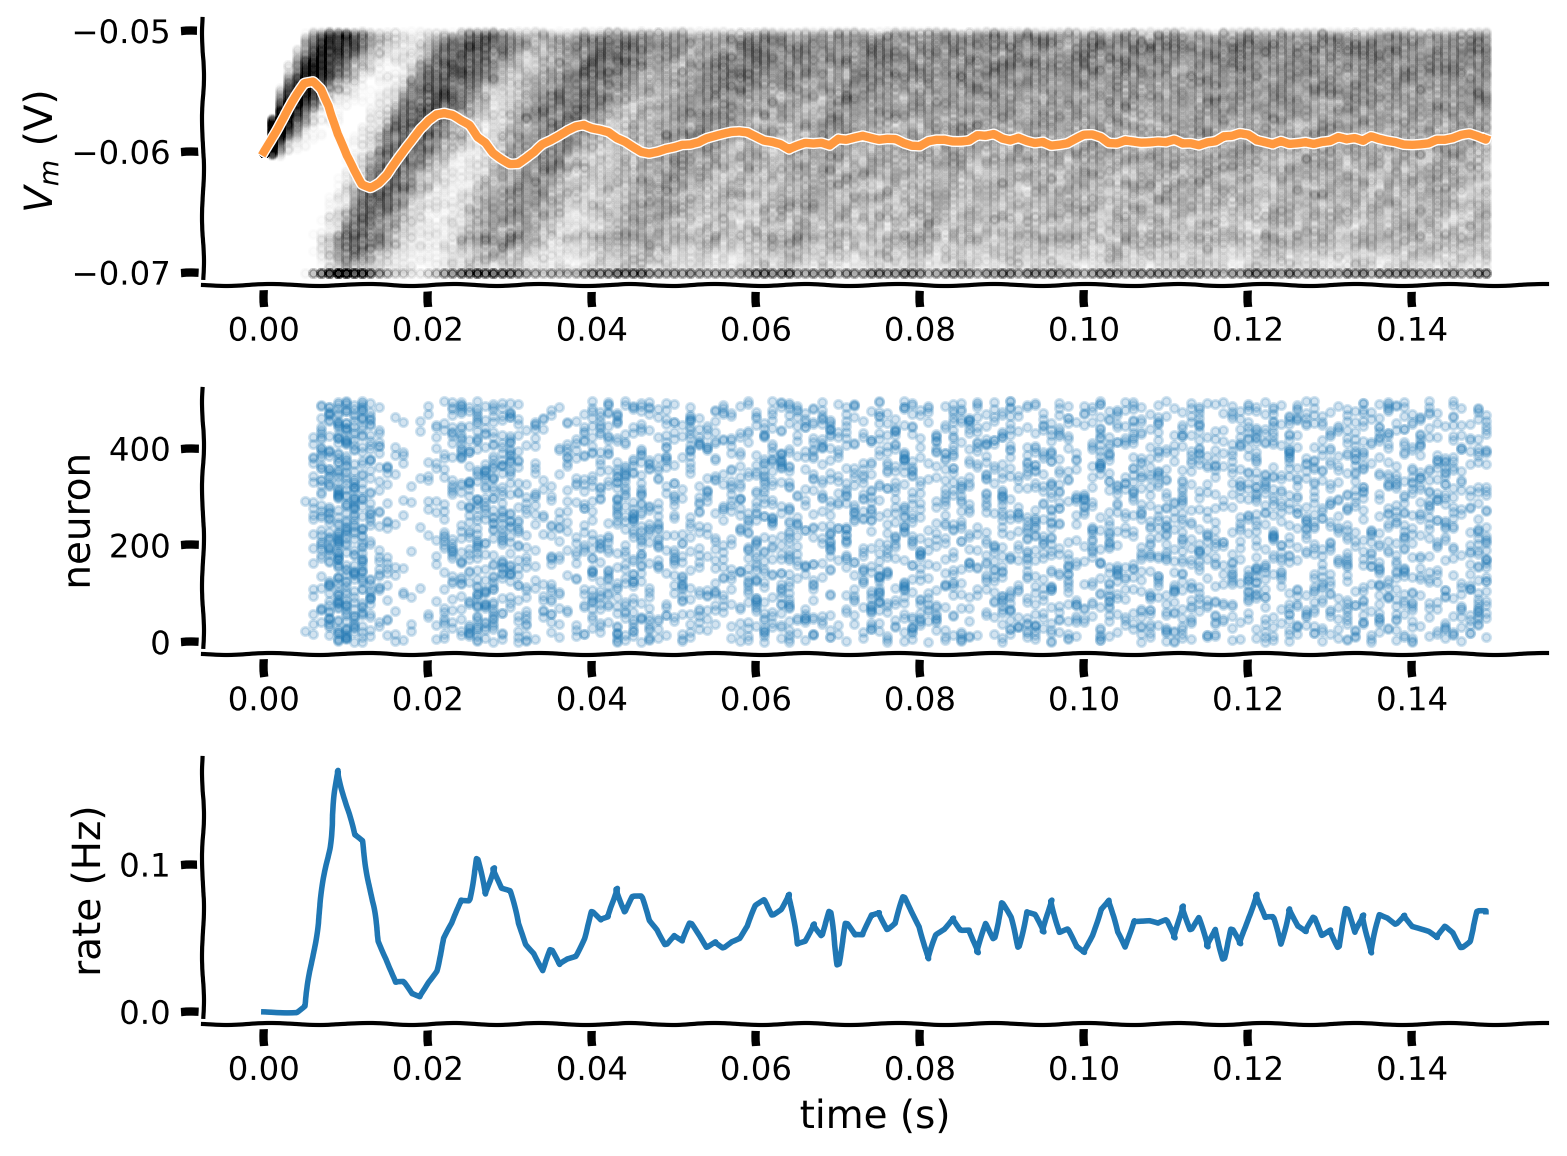

In [ ]:

# Set random number generator
np.random.seed(2020)

# Initialize step_end, t_range, n, v_n and i
t_range = np.arange(0, t_max, dt)
step_end = len(t_range)
n = 500
v_n = el * np.ones([n, step_end])
i = i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * (2 * np.random.random([n, step_end]) - 1))

# Initialize spikes and spikes_n
spikes = {j: [] for j in range(n)}
spikes_n = np.zeros([step_end])

# Loop over time steps
for step, t in enumerate(t_range):

  # Skip first iteration
  if step == 0:
    continue

  # Compute v_n
  v_n[:, step] = v_n[:, step - 1] + (dt / tau) * (el - v_n[:, step - 1] + r*i[:, step])

  # Loop over simulations
  for j in range(n):

    # Check if voltage above threshold
    if v_n[j, step] >= vth:

      # Reset to reset voltage
      v_n[j, step] = vr

      # Add this spike time
      spikes[j] += [t]

      # Add spike count to this step
      spikes_n[step] += 1


# Collect mean Vm and mean spiking rate
v_mean = np.mean(v_n, axis=0)
spikes_mean =  spikes_n / n

with plt.xkcd():
  # Initialize the figure
  plt.figure()

  # Plot simulations and sample mean
  ax1 = plt.subplot(3, 1, 1)
  for j in range(n):
    plt.scatter(t_range, v_n[j], color="k", marker=".", alpha=0.01)
  plt.plot(t_range, v_mean, 'C1', alpha=0.8, linewidth=3)
  plt.ylabel('$V_m$ (V)')

  # Plot spikes
  plt.subplot(3, 1, 2, sharex=ax1)
  # for each neuron j: collect spike times and plot them at height j
  for j in range(n):
    times = np.array(spikes[j])
    plt.scatter(times, j * np.ones_like(times), color="C0", marker=".", alpha=0.2)

  plt.ylabel('neuron')

  # Plot firing rate
  plt.subplot(3, 1, 3, sharex=ax1)
  plt.plot(t_range, spikes_mean)
  plt.xlabel('time (s)')
  plt.ylabel('rate (Hz)')

  plt.tight_layout()

# Section 3: Boolean indexes

In [ ]:
a = np.array([1,2,3])
b = a >= 2
print(b)

[False  True  True]


In [ ]:
print(a[b])

[2 3]


In [ ]:
print(a[a>=2])

[2 3]


In [ ]:
v_rest = (v_n[:,step] == vr)
print(v_n[v_rest,step])

[-0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07
 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07
 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07 -0.07]


In [ ]:
print(step)

149


# Coding Exercise 3: Using Boolean indexing

We can avoid looping all neurons in each time step by identifying with boolean arrays the indexes of neurons that spiked in the previous step.

In the example below, v_rest is a boolean numpy array with True in each index of v_n with value vr at time index step:

```
v_rest = (v_n[:,step] == vr)
print(v_n[v_rest,step])
  --> [vr, ..., vr]
```

The function np.where returns indexes of boolean arrays with True values.

You may use the helper function plot_all that implements the figure from the previous exercise.

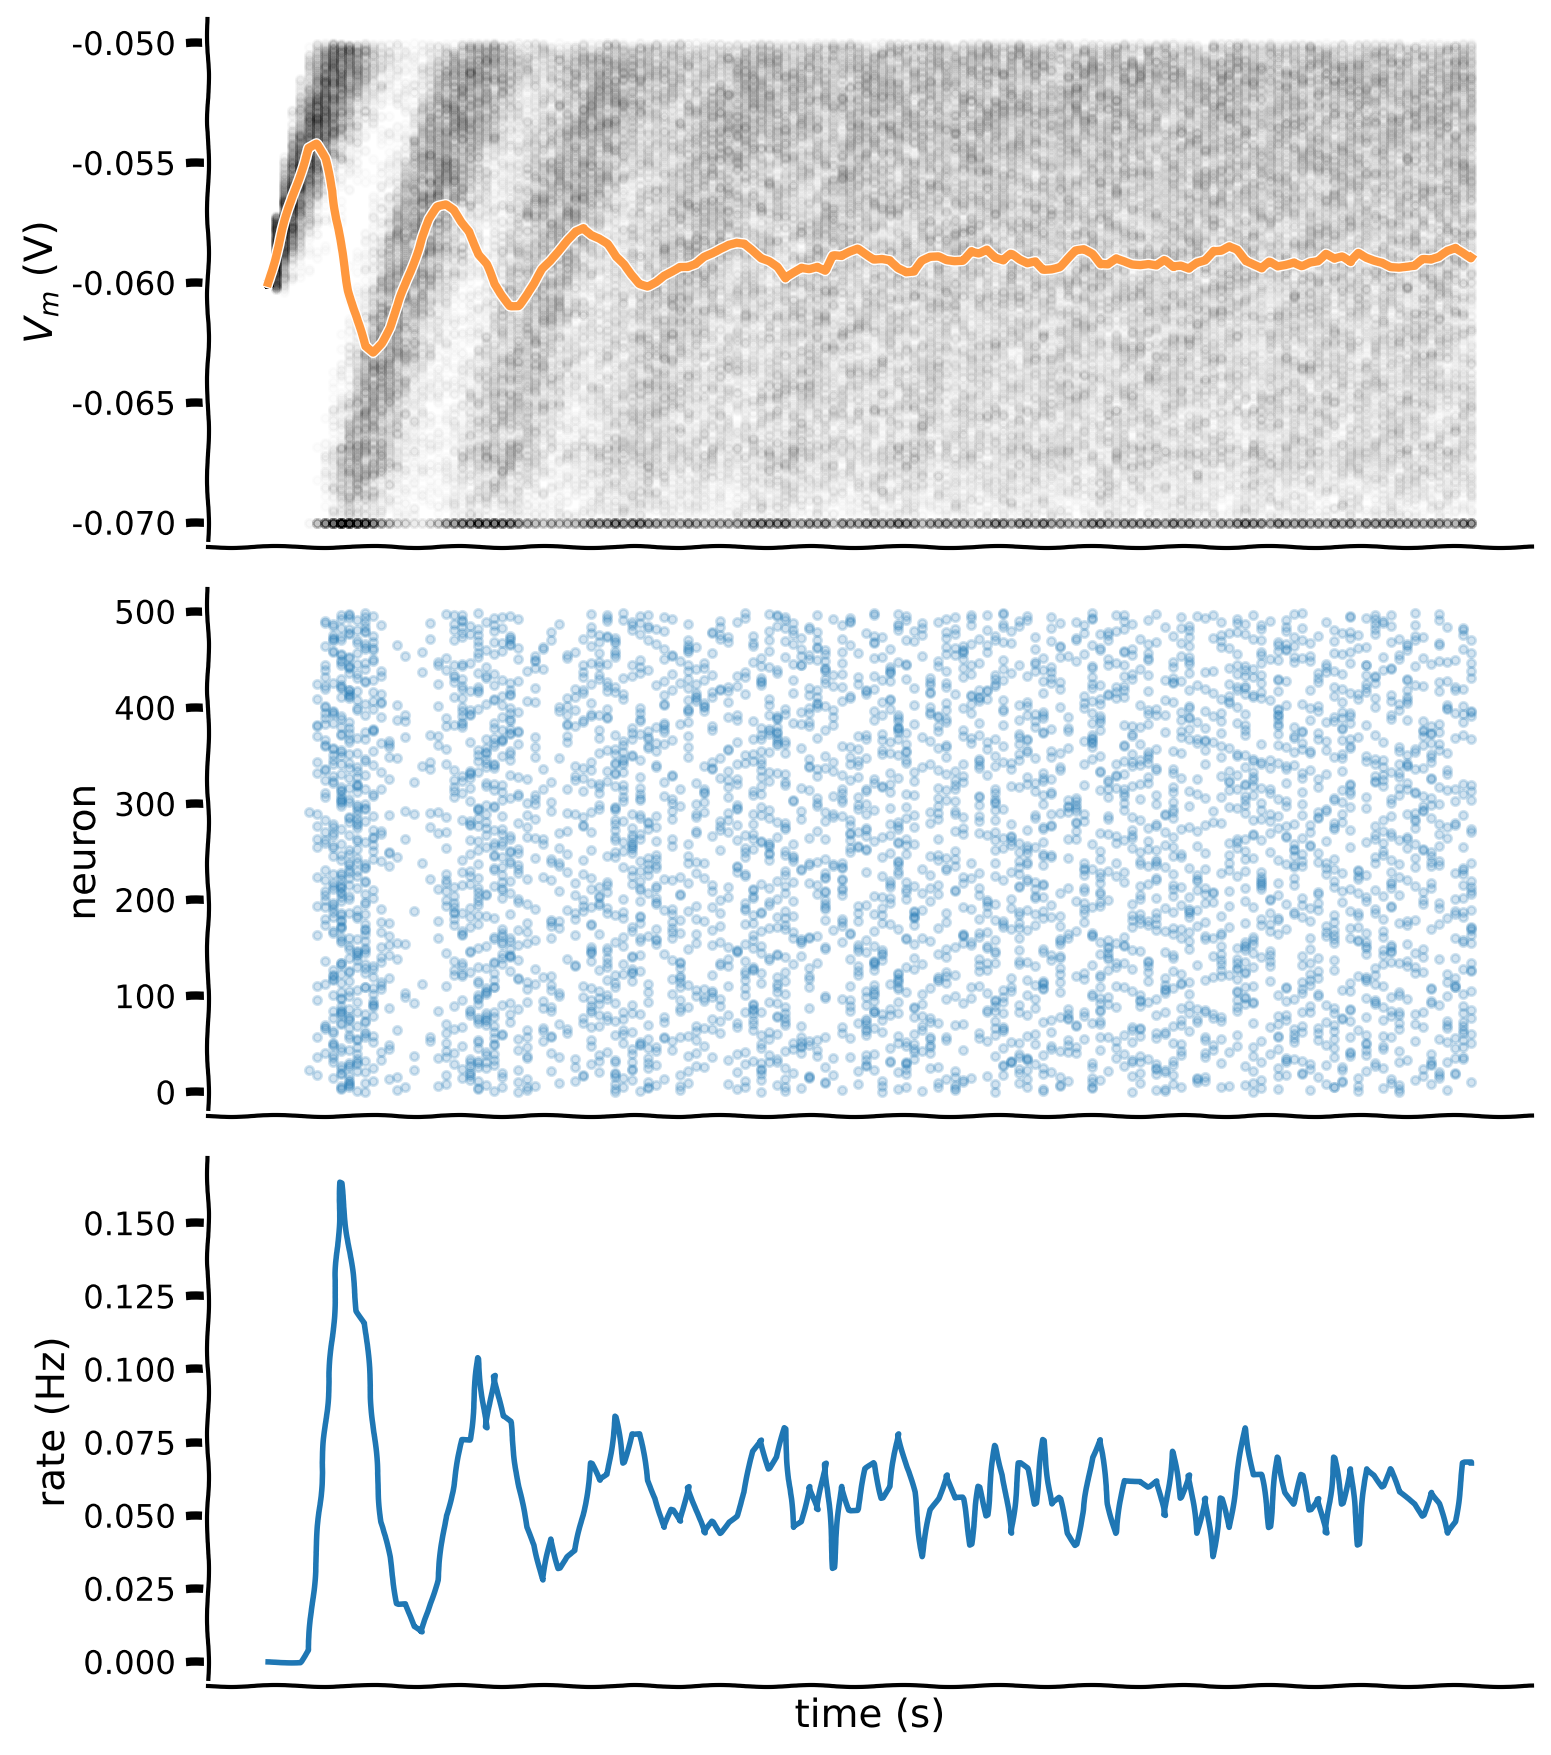

In [ ]:

# Set random number generator
np.random.seed(2020)

# Initialize step_end, t_range, n, v_n and i
t_range = np.arange(0, t_max, dt)
step_end = len(t_range)
n = 500
v_n = el * np.ones([n, step_end])
i = i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * (2 * np.random.random([n, step_end]) - 1))

# Initialize spikes and spikes_n
spikes = {j: [] for j in range(n)}
spikes_n = np.zeros([step_end])

# Loop over time steps
for step, t in enumerate(t_range):

  # Skip first iteration
  if step == 0:
    continue

  # Compute v_n
  v_n[:, step] = v_n[:, step - 1] + (dt / tau) * (el - v_n[:, step - 1] + r*i[:, step])

  # Initialize boolean numpy array `spiked` with v_n > v_thr
  spiked = (v_n[:,step] >= vth)

  # Set relevant values of v_n to resting potential using spiked
  v_n[spiked,step] = vr

  # Collect spike times
  for j in np.where(spiked)[0]:
    spikes[j] += [t]
    spikes_n[step] += 1

# Collect mean spiking rate
spikes_mean = spikes_n / n

# Plot multiple realizations of Vm, spikes and mean spike rate
with plt.xkcd():
  plot_all(t_range, v_n, spikes=spikes, spikes_mean=spikes_mean)

# Coding Exercise 4: Making a binary raster plot

A binary raster plot represents spike times as 1s in a binary grid initialized with 0s. We start with a numpy array raster of zeros with shape (neurons, time steps), and represent a spike from neuron 5 at time step 20 as raster(5,20)=1, for example.

The binary raster plot is much more efficient than the previous method by plotting the numpy array raster as an image:
```
plt.imshow(raster, cmap='Greys', origin='lower', aspect='auto')
```
Suggestions

    At each time step:
        Initialize boolean numpy array spiked with Vn(t)≥Vth
        Set to vr indexes of v_n using spiked
        Set to 1 indexes of numpy array raster using spiked


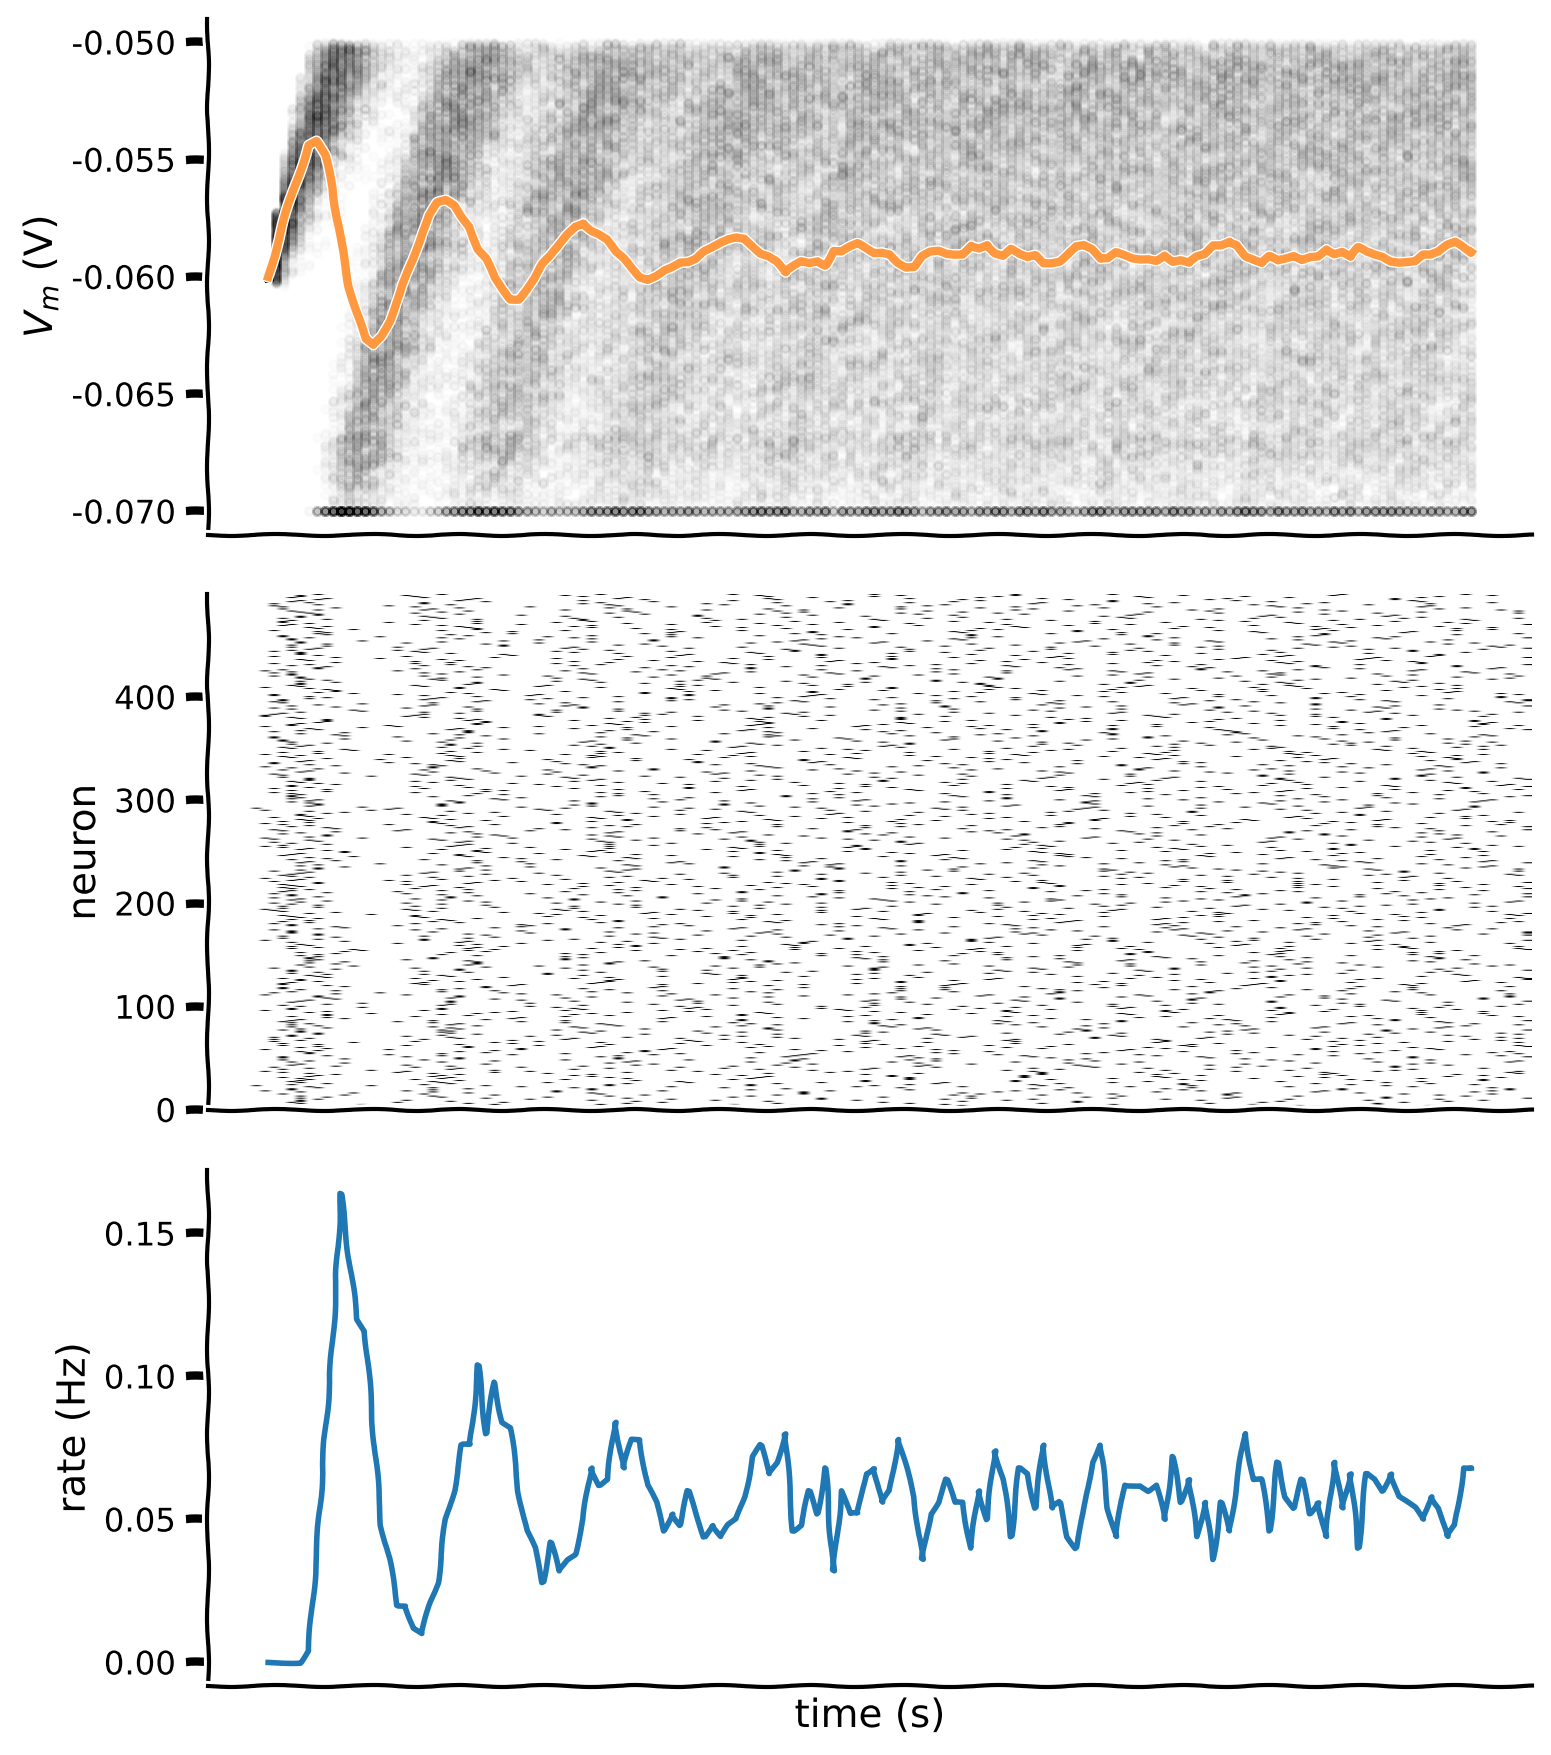

In [ ]:

# Set random number generator
np.random.seed(2020)

# Initialize step_end, t_range, n, v_n and i
t_range = np.arange(0, t_max, dt)
step_end = len(t_range)
n = 500
v_n = el * np.ones([n, step_end])
i = i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * (2 * np.random.random([n, step_end]) - 1))

# Initialize binary numpy array for raster plot
raster = np.zeros([n,step_end])

# Loop over time steps
for step, t in enumerate(t_range):

  # Skip first iteration
  if step==0:
    continue

  # Compute v_n
  v_n[:, step] = v_n[:, step - 1] + (dt / tau) * (el - v_n[:, step - 1] + r*i[:, step])

  # Initialize boolean numpy array `spiked` with v_n > v_thr
  spiked = (v_n[:,step] >= vth)

  # Set relevant values of v_n to v_reset using spiked
  v_n[spiked,step] = vr

  # Set relevant elements in raster to 1 using spiked
  raster[spiked,step] = 1.

# Plot multiple realizations of Vm, spikes and mean spike rate
with plt.xkcd():
  plot_all(t_range, v_n, raster)

# Section 4: Refractory period

## Coding Exercise 5: Investigating refactory periods

Investigate the effect of (absolute) refractory period tref on the evolution of output rate λ(t). Add refractory period tref=10 ms after each spike, during which V(t) is clamped to Vreset.

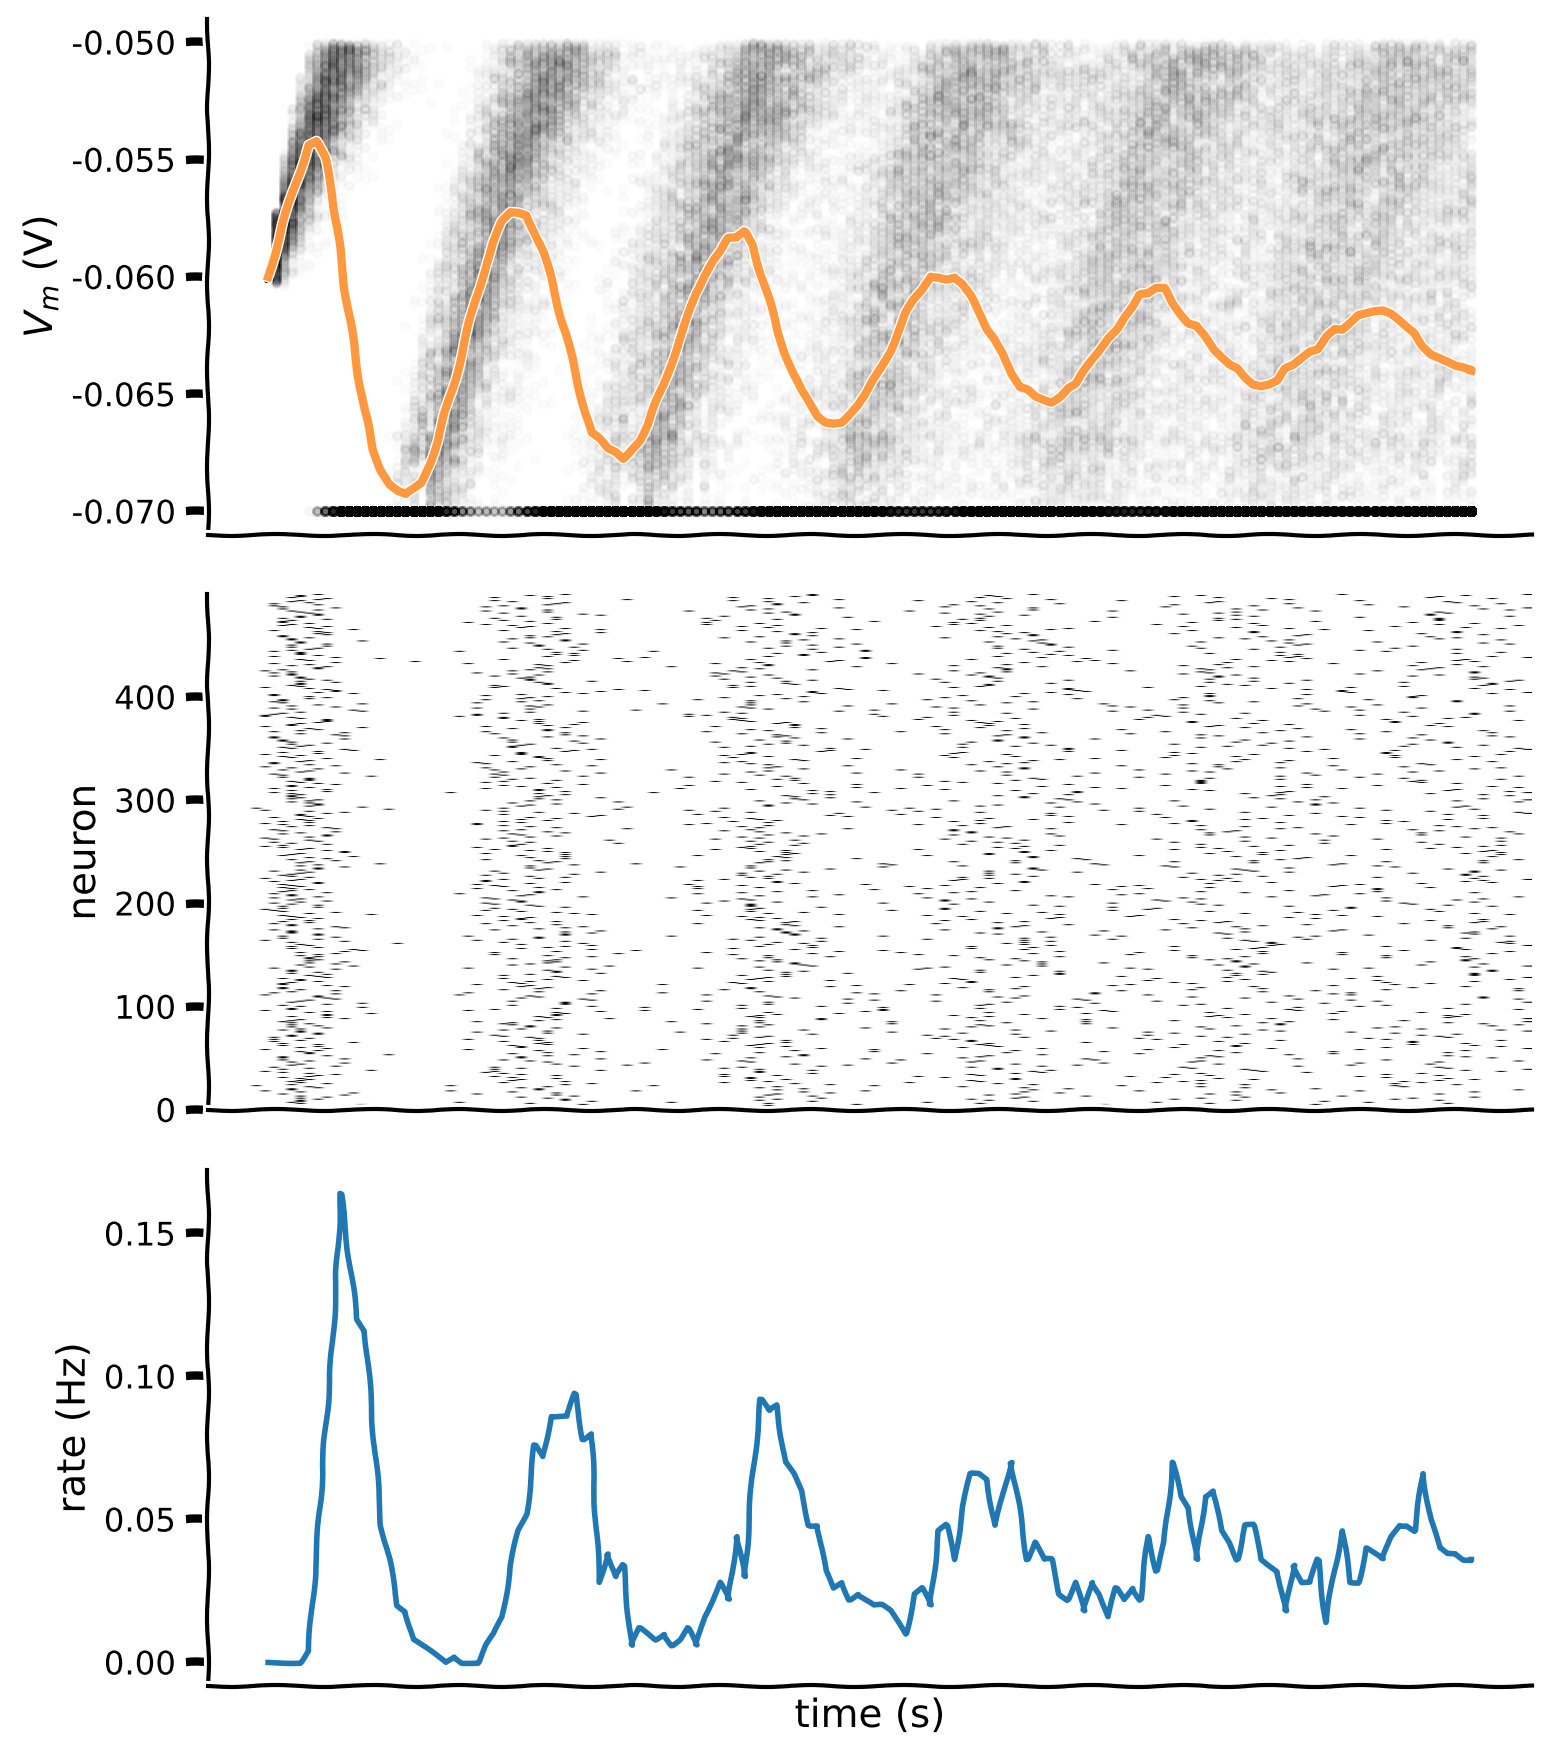

In [ ]:

# Set random number generator
np.random.seed(2020)

# Initialize step_end, t_range, n, v_n and i
t_range = np.arange(0, t_max, dt)
step_end = len(t_range)
n = 500
v_n = el * np.ones([n, step_end])
i = i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * (2 * np.random.random([n, step_end]) - 1))

# Initialize binary numpy array for raster plot
raster = np.zeros([n,step_end])

# Initialize t_ref and last_spike
t_ref = 0.01
last_spike = -t_ref * np.ones([n])

# Loop over time steps
for step, t in enumerate(t_range):

  # Skip first iteration
  if step == 0:
    continue

  # Compute v_n
  v_n[:, step] = v_n[:, step - 1] + (dt / tau) * (el - v_n[:, step - 1] + r*i[:, step])

  # Initialize boolean numpy array `spiked` with v_n > v_thr
  spiked = (v_n[:,step] >= vth)

  # Set relevant values of v_n to v_reset using spiked
  v_n[spiked,step] = vr

  # Set relevant elements in raster to 1 using spiked
  raster[spiked,step] = 1.

  # Initialize boolean numpy array clamped using last_spike, t and t_ref
  clamped = (last_spike + t_ref > t)

  # Reset clamped neurons to vr using clamped
  v_n[clamped,step] = vr

  # Update numpy array last_spike with time t for spiking neurons
  last_spike[spiked] = t

# Plot multiple realizations of Vm, spikes and mean spike rate
with plt.xkcd():
  plot_all(t_range, v_n, raster)

# TODO: clamping logic below is NOT FULLY CLEAR
(Investigate this step: Reset membrane potential and clamp)

# Coding Exercise 6: Rewriting code with functions

We will now re-organize parts of the code from the previous exercise with functions. You need to complete the function spike_clamp() to update V(t) and deal with spiking and refractoriness

In [ ]:

def ode_step(v, i, dt):
  """
  Evolves membrane potential by one step of discrete time integration

  Args:
    v (numpy array of floats)
      membrane potential at previous time step of shape (neurons)

    i (numpy array of floats)
      synaptic input at current time step of shape (neurons)

    dt (float)
      time step increment

  Returns:
    v (numpy array of floats)
      membrane potential at current time step of shape (neurons)
  """
  v = v + dt/tau * (el - v + r*i)

  return v

In [ ]:
def spike_clamp(v, delta_spike):
  """
  Resets membrane potential of neurons if v>= vth
  and clamps to vr if interval of time since last spike < t_ref

  Args:
    v (numpy array of floats)
      membrane potential of shape (neurons)

    delta_spike (numpy array of floats)
      interval of time since last spike of shape (neurons)

  Returns:
    v (numpy array of floats)
      membrane potential of shape (neurons)
    spiked (numpy array of floats)
      boolean array of neurons that spiked  of shape (neurons)
  """

  # Boolean array spiked indexes neurons with v>=vth
  spiked = (v >= vth)
  v[spiked] = vr

  # Boolean array clamped indexes refractory neurons
  clamped = (t_ref > delta_spike)
  v[clamped] = vr

  return v, spiked

In [ ]:

# Set random number generator
np.random.seed(2020)

# Initialize step_end, t_range, n, v_n and i
t_range = np.arange(0, t_max, dt)
step_end = len(t_range)
n = 500
v_n = el * np.ones([n, step_end])
i = i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * (2 * np.random.random([n, step_end]) - 1))

# Initialize binary numpy array for raster plot
raster = np.zeros([n,step_end])

# Initialize t_ref and last_spike
mu = 0.01
sigma = 0.007
t_ref = mu + sigma*np.random.normal(size=n)
t_ref[t_ref<0] = 0
last_spike = -t_ref * np.ones([n])

# Loop over time steps
for step, t in enumerate(t_range):

  # Skip first iteration
  if step==0:
    continue

  # Compute v_n
  v_n[:,step] = ode_step(v_n[:,step-1], i[:,step], dt)

  # Reset membrane potential and clamp
  v_n[:,step], spiked = spike_clamp(v_n[:,step], t - last_spike)

  # Update raster and last_spike
  raster[spiked,step] = 1.
  last_spike[spiked] = t

# Plot multiple realizations of Vm, spikes and mean spike rate
with plt.xkcd():
  plot_all(t_range, v_n, raster)

[1.01574587e-02 0.00000000e+00 1.12062798e-02 1.64733553e-02
 1.63187237e-02 1.52402384e-02 8.40727273e-03 1.91642587e-02
 1.18897371e-02 1.12691325e-02 1.51705771e-02 7.36865909e-03
 1.04546049e-02 1.18490688e-02 1.20098812e-02 1.23987567e-02
 1.72839253e-02 2.33288795e-03 1.37288019e-02 1.55156736e-02
 1.35191861e-03 1.43426227e-02 1.17418516e-04 5.66940100e-03
 2.83771226e-02 8.14846227e-03 5.98020804e-03 1.00027152e-03
 5.24395340e-03 1.53811824e-02 4.60273884e-03 2.01949293e-02
 1.07471707e-02 4.83550600e-03 0.00000000e+00 1.38918447e-02
 9.92479536e-03 1.93490784e-02 1.28228777e-02 6.05633374e-03
 1.27065680e-02 2.30025592e-03 7.04638263e-04 1.82124881e-02
 1.07704316e-02 6.84690814e-03 1.06393845e-02 1.00737478e-02
 1.29228512e-02 1.93916898e-02 1.26770348e-02 1.44144821e-02
 4.07803942e-03 3.02866191e-03 4.29331757e-03 9.79353638e-03
 2.03197615e-02 1.11301776e-02 1.16424468e-02 1.73427185e-02
 1.97031175e-02 0.00000000e+00 5.14062167e-03 1.28762749e-02
 0.00000000e+00 4.445839

# Coding Exercise 7: Making a LIF class

In this exercise we'll practice with Python classes by implementing LIFNeurons, a class that evolves and keeps state of multiple realizations of LIF neurons.

Several attributes are used to keep state of our neurons:

Ran for 0.15s in 150 steps.


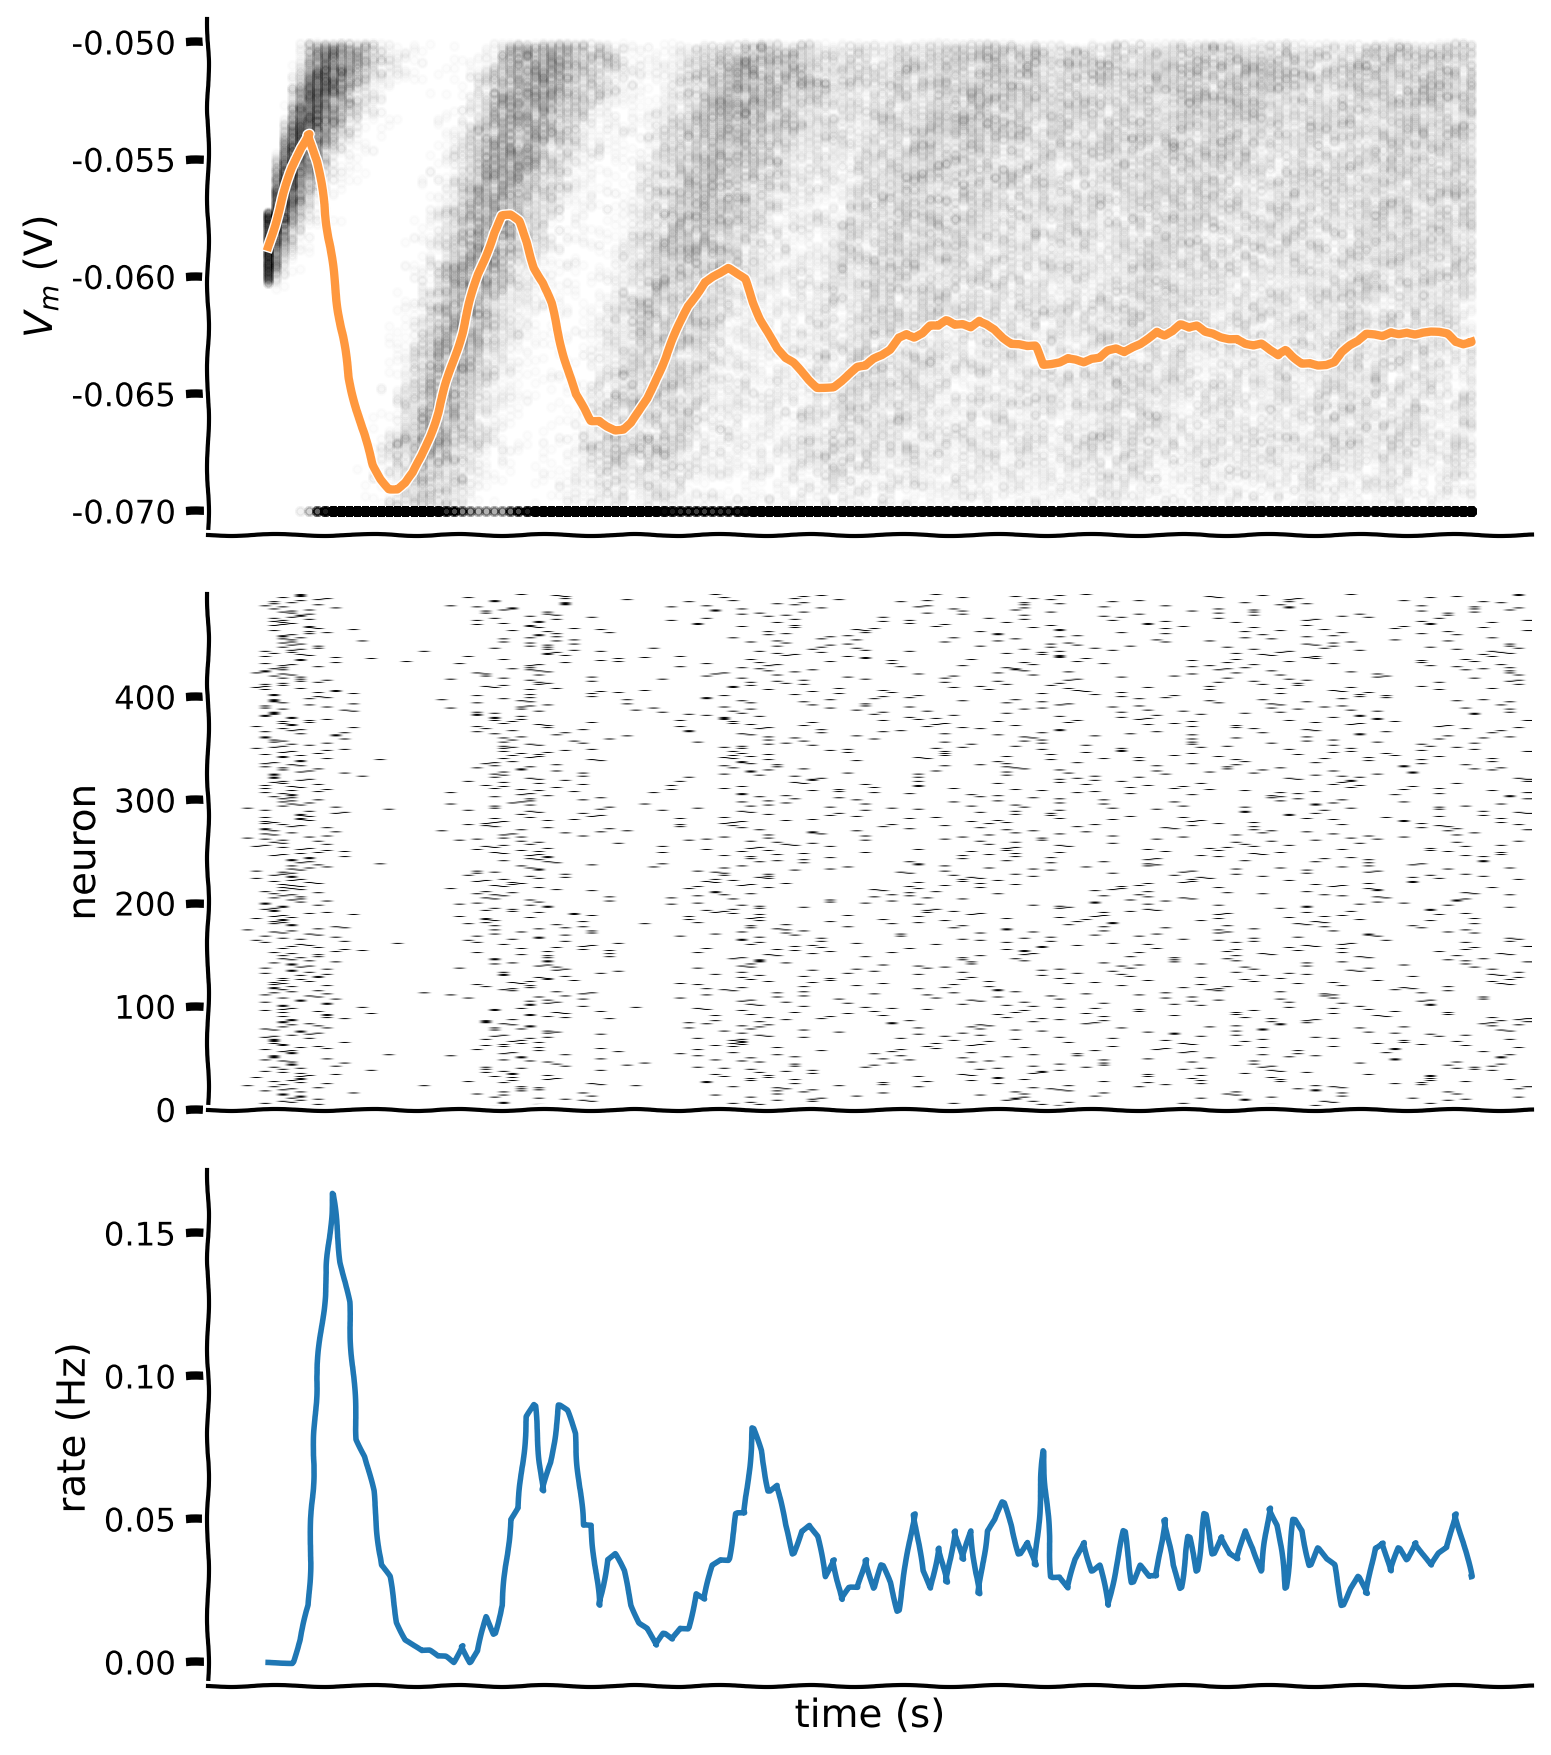

In [ ]:

# Simulation class
class LIFNeurons:
  """
  Keeps track of membrane potential for multiple realizations of LIF neuron,
  and performs single step discrete time integration.
  """
  def __init__(self, n, t_ref_mu=0.01, t_ref_sigma=0.002,
               tau=20e-3, el=-60e-3, vr=-70e-3, vth=-50e-3, r=100e6):

    # Neuron count
    self.n = n

    # Neuron parameters
    self.tau = tau        # second
    self.el = el          # milivolt
    self.vr = vr          # milivolt
    self.vth = vth        # milivolt
    self.r = r            # ohm

    # Initializes refractory period distribution
    self.t_ref_mu = t_ref_mu
    self.t_ref_sigma = t_ref_sigma
    self.t_ref = self.t_ref_mu + self.t_ref_sigma * np.random.normal(size=self.n)
    self.t_ref[self.t_ref<0] = 0

    # State variables
    self.v = self.el * np.ones(self.n)
    self.spiked = self.v >= self.vth
    self.last_spike = -self.t_ref * np.ones([self.n])
    self.t = 0.
    self.steps = 0


  def ode_step(self, dt, i):

    # Update running time and steps
    self.t += dt
    self.steps += 1

    # One step of discrete time integration of dt
    self.v = self.v + dt / self.tau * (self.el - self.v + self.r * i)

    # Spike and clamp
    self.spiked = (self.v >= self.vth)
    self.v[self.spiked] = self.vr
    self.last_spike[self.spiked] = self.t
    clamped = (self.t_ref > self.t-self.last_spike)
    self.v[clamped] = self.vr

    self.last_spike[self.spiked] = self.t

# Set random number generator
np.random.seed(2020)

# Initialize step_end, t_range, n, v_n and i
t_range = np.arange(0, t_max, dt)
step_end = len(t_range)
n = 500
v_n = el * np.ones([n, step_end])
i = i_mean * (1 + 0.1 * (t_max / dt)**(0.5) * (2 * np.random.random([n, step_end]) - 1))

# Initialize binary numpy array for raster plot
raster = np.zeros([n,step_end])

# Initialize neurons
neurons = LIFNeurons(n)

# Loop over time steps
for step, t in enumerate(t_range):

  # Call ode_step method
  neurons.ode_step(dt, i[:,step])

  # Log v_n and spike history
  v_n[:,step] = neurons.v
  raster[neurons.spiked, step] = 1.

# Report running time and steps
print(f'Ran for {neurons.t:.3}s in {neurons.steps} steps.')

# Plot multiple realizations of Vm, spikes and mean spike rate
with plt.xkcd():
  plot_all(t_range, v_n, raster)